# **Pipeline Completo: CNN + RAG + LLM**

En este siguiente apartado integramos los tres componentes del sistema ECGAssistant
en un pipeline completo end-to-end.

El flujo es el siguiente:
```
Señal ECG → CNN clasifica → Normal/Anormal → RAG busca contexto clínico → LLM genera explicación
```

Cada componente aporta algo diferente al resultado final:
- **CNN:** clasificación rápida y objetiva de la señal (F1 = 0.9867)
- **RAG:** ancla las respuestas en documentación clínica real, reduciendo alucinaciones
- **LLM fine-tuned:** genera explicaciones en español con tono clínico apropiado

In [26]:
# Instalación de dependencias
%pip install -q torch transformers accelerate peft bitsandbytes
%pip install -q faiss-cpu sentence-transformers

In [27]:
# Montar Drive si usamos Colab (comentamos si ejecutamos en local)
#from google.colab import drive
#drive.mount('/content/drive')
#os.chdir("/content/drive/MyDrive/Colab Notebooks/ECGAssistant_Sprint1")

import os
print("Directorio:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio: /content/drive/.shortcut-targets-by-id/1acOp95JDTEWtgyHkn2BDLpHG-oeo8sXh/ECGAssistant_Sprint1


In [28]:
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login
from sentence_transformers import SentenceTransformer
import faiss

from google.colab import userdata
login(token=userdata.get('HF_TOKEN'))

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Carga de la CNN

Cargamos la arquitectura y los pesos entrenados del modelo CNN.

In [29]:
class ECG_CNN(nn.Module):

    def __init__(self):
        super(ECG_CNN, self).__init__()

        # Bloque 1: detecta patrones básicos como el pico R del QRS
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(16)

        # Bloque 2: combina los patrones básicos para detectar anomalías
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(32)

        # MaxPool reduce la dimensión temporal: 288 → 144 → 72
        self.pool    = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)

        # Clasificador: 32 canales × 72 puntos = 2304 features → 64 → 2 clases
        self.fc1 = nn.Linear(32 * 72, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


cnn_model = ECG_CNN().to(device)
cnn_model.load_state_dict(torch.load("ecg_cnn.pt", map_location=device))
cnn_model.eval()
print("CNN cargada correctamente")

CNN cargada correctamente


In [30]:
def clasificar_ecg(signal):
    """
    Clasifica una señal ECG usando la CNN entrenada.

    Args:
        signal: array numpy de 288 puntos (un latido)

    Returns:
        tuple: (clase, confianza)
            - clase: 0 (normal) o 1 (anormal)
            - confianza: probabilidad de la clase predicha (0-100%)
    """
    # [288] → [1, 1, 288] = [batch, canales, tiempo]
    x = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = cnn_model(x)
        probs  = torch.softmax(logits, dim=1)
        clase  = torch.argmax(probs, dim=1).item()
        confianza = probs[0, clase].item() * 100

    return clase, confianza

## 2. Carga del sistema RAG

Cargamos el índice FAISS y los chunks generados en el RAG.

In [31]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# Cargamos el índice y los chunks precomputados
index = faiss.read_index("faiss_index.bin")

with open("chunks.json", "r", encoding="utf-8") as f:
    data          = json.load(f)
    all_chunks    = data["chunks"]
    chunk_sources = data["sources"]

print(f"Índice FAISS cargado: {index.ntotal} vectores")
print(f"Chunks disponibles: {len(all_chunks)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Índice FAISS cargado: 6 vectores
Chunks disponibles: 6


In [32]:
def buscar_contexto(consulta, k=3):
    """
    Busca los k fragmentos más relevantes para una consulta.

    Args:
        consulta: texto de búsqueda
        k: número de resultados a devolver
    """
    query_embedding          = embedding_model.encode([consulta]).astype(np.float32)
    distancias, indices      = index.search(query_embedding, k)

    resultados = []
    for i, idx in enumerate(indices[0]):
        resultados.append({
            "chunk"    : all_chunks[idx],
            "fuente"   : chunk_sources[idx],
            "distancia": distancias[0][i]
        })

    return resultados

## 3. Carga del LLM fine-tuneado

Cargamos Gemma 3 4B con los adaptadores LoRA entrenados.
La cuantización en 4-bit permite cargarlo en Colab sin quedarse sin memoria.

In [33]:
import gc

# Liberamos CNN y embeddings antes de cargar Gemma
del cnn_model
del embedding_model
gc.collect()
torch.cuda.empty_cache()
print("Memoria liberada")

Memoria liberada


In [34]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model_id = "google/gemma-3-4b-it"

print("Cargando modelo base (puede tardar unos minutos)...")
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
llm_base  = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
print("Modelo base cargado")

# Cargamos los adaptadores LoRA con el conocimiento clínico específico
llm_model = PeftModel.from_pretrained(llm_base, "./gemma3_qlora")
llm_model.eval()
print("Adaptadores LoRA cargados")

Cargando modelo base (puede tardar unos minutos)...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Modelo base cargado
Adaptadores LoRA cargados


## 4. Prompt de sistema

Definimos el comportamiento del asistente. Es el mismo system prompt
usado durante el fine-tuning para mantener consistencia entre el
entrenamiento y la inferencia.

In [35]:
SYSTEM_PROMPT = """Eres ECGAssistant, un asistente médico especializado en la
interpretación de electrocardiogramas (ECG). Tu función es explicar los resultados
de un modelo de deep learning (CNN) que clasifica señales ECG como normales o anormales.

Reglas:
1. Siempre basa tu respuesta en el resultado de la CNN proporcionado por el usuario.
2. Explica de forma clara y precisa el significado clínico del resultado.
3. Cuando sea relevante, menciona posibles arritmias, estudios complementarios o recomendaciones.
4. Responde siempre en español.
5. Incluye siempre un aviso indicando que este análisis no reemplaza la consulta
   de un profesional médico."""

In [36]:
def generar_respuesta(prompt, max_tokens=500):
    """Genera una respuesta usando el LLM fine-tuneado."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True)

    if "token_type_ids" not in inputs:
        inputs["token_type_ids"] = torch.zeros_like(inputs["input_ids"])

    inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output = llm_model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            use_cache=True,
            repetition_penalty=1.3 #penaliza repeticiones
        )

    respuesta = tokenizer.decode(output[0], skip_special_tokens=True)

    # Extraemos solo la parte de la respuesta
    if "### Respuesta:" in respuesta:
        respuesta = respuesta.split("### Respuesta:")[-1].strip()

    return respuesta

## 5. Pipeline completo

Implementamos la función principal que orquesta los tres componentes.
Recibe una señal ECG cruda y devuelve la clasificación, el contexto
recuperado y la explicación clínica generada.

In [37]:
def ecg_assistant(signal, verbose=True):
    """
    Pipeline completo de ECGAssistant.

    Args:
        signal: array numpy de 288 puntos (un latido ECG)
        verbose: si True, imprime el progreso de cada paso

    Returns:
        dict con clasificación, fuentes RAG y explicación generada
    """
    resultado = {}

    # PASO 1: Clasificación con CNN
    clase, confianza = clasificar_ecg(signal)
    etiqueta = "Normal" if clase == 0 else "Anormal"
    resultado["clasificacion"] = {
        "clase"    : clase,
        "etiqueta" : etiqueta,
        "confianza": confianza
    }
    if verbose:
        print(f"[CNN] {etiqueta} ({confianza:.1f}% confianza)")

    # PASO 2: Recuperación de contexto con RAG
    consulta = "ritmo sinusal normal ECG características" if clase == 0 \
               else "arritmia cardiaca diagnóstico tratamiento ECG anormal"

    contextos      = buscar_contexto(consulta, k=3)
    contexto_texto = "\n\n".join([c["chunk"] for c in contextos])

    resultado["rag"] = {
        "consulta": consulta,
        "fuentes" : [c["fuente"] for c in contextos],
    }
    if verbose:
        print(f"[RAG] Contexto de: {', '.join(resultado['rag']['fuentes'])}")

    # PASO 3: Generación de explicación con LLM
    prompt = f"""{SYSTEM_PROMPT}

### Contexto clínico:
{contexto_texto}

### Instrucción:
El modelo CNN ha clasificado este ECG como {etiqueta} con una confianza
del {confianza:.1f}%. Explica este resultado al paciente y proporciona
recomendaciones apropiadas.

### Respuesta:
"""
    resultado["explicacion"] = generar_respuesta(prompt)

    if verbose:
        print(f"[LLM] Explicación generada")

    return resultado


def mostrar_resultado(resultado):
    """Muestra el resultado del pipeline de forma legible."""
    print("=" * 60)
    print("RESULTADO ECGAssistant")
    print("=" * 60)
    print(f"\nCLASIFICACIÓN CNN:")
    print(f"  Resultado:  {resultado['clasificacion']['etiqueta']}")
    print(f"  Confianza:  {resultado['clasificacion']['confianza']:.1f}%")
    print(f"\nFUENTES RAG:")
    for fuente in resultado['rag']['fuentes']:
        print(f"  - {fuente}")
    print(f"\nEXPLICACIÓN:")
    print("-" * 60)
    print(resultado['explicacion'])
    print("-" * 60)

## 6. Pruebas con señales reales

Ejecutamos el pipeline con señales del conjunto de test para verificar
que los tres componentes se integran correctamente.

In [38]:
# Cargamos los datos de test
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print(f"Muestras de test: {X_test.shape[0]}")
print(f"Normales: {np.sum(y_test == 0)} | Anormales: {np.sum(y_test == 1)}")

# Seleccionamos 2 normales y 2 anormales
indices_normales  = np.where(y_test == 0)[0][:2]
indices_anormales = np.where(y_test == 1)[0][:2]
indices_prueba    = np.concatenate([indices_normales, indices_anormales])

Muestras de test: 14748
Normales: 10449 | Anormales: 4299


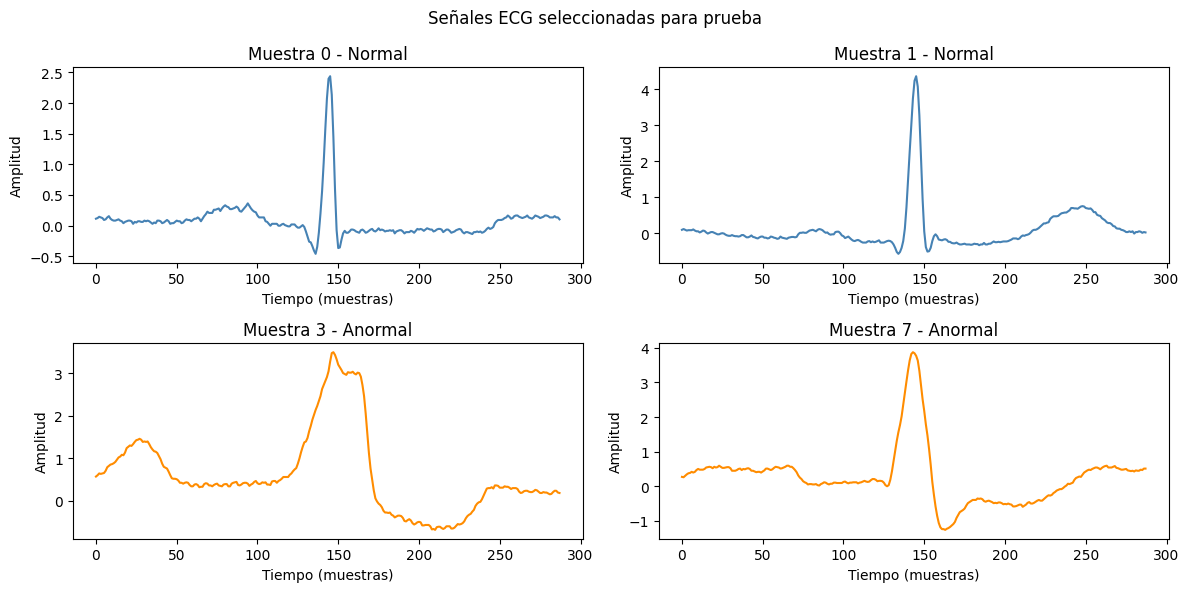

In [39]:
# Visualizamos las señales seleccionadas
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, idx in enumerate(indices_prueba):
    ax           = axes[i // 2, i % 2]
    etiqueta_real = "Normal" if y_test[idx] == 0 else "Anormal"
    color         = "steelblue" if y_test[idx] == 0 else "darkorange"
    ax.plot(X_test[idx], color=color)
    ax.set_title(f"Muestra {idx} - {etiqueta_real}")
    ax.set_xlabel("Tiempo (muestras)")
    ax.set_ylabel("Amplitud")

plt.suptitle("Señales ECG seleccionadas para prueba", fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
# Recargamos la CNN y el modelo de embeddings para las pruebas
cnn_model = ECG_CNN().to(device)
cnn_model.load_state_dict(torch.load("ecg_cnn.pt", map_location=device))
cnn_model.eval()
print("CNN recargada")

embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
print("Embedding model recargado")

CNN recargada


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model recargado


In [41]:
# Prueba 1: señal normal
print("\n" + "="*60)
print("PRUEBA 1: Señal NORMAL")
print("="*60)
resultado_normal = ecg_assistant(X_test[indices_normales[0]])
mostrar_resultado(resultado_normal)


PRUEBA 1: Señal NORMAL
[CNN] Normal (100.0% confianza)
[RAG] Contexto de: Taquicardia_ventricular.md, bloqueo_av.md, fibrilacion_ventricular.md
[LLM] Explicación generada
RESULTADO ECGAssistant

CLASIFICACIÓN CNN:
  Resultado:  Normal
  Confianza:  100.0%

FUENTES RAG:
  - Taquicardia_ventricular.md
  - bloqueo_av.md
  - fibrilacion_ventricular.md

EXPLICACIÓN:
------------------------------------------------------------
Según nuestro análisis, el ECG presentado corresponde a "Normal" con **confianza del 100%**. Esto significa que todas las características evaluadas – frecuencia, intervalos RR, morfología basal– coinciden perfectamente con valores dentro del rango considerado saludable según nuestros algoritmos entrenados.  Su corazón late normalmente! Para mantener ese estado óptimo te recomiendo realizar controles médicos periódicos donde podamos revisar juntos cualquier cambio que observemos en tus signos vitales. ¡Cuídate mucho! Recuerda que esta información orientativa NO sustitu

In [42]:
# Prueba 2: señal anormal
print("\n" + "="*60)
print("PRUEBA 2: Señal ANORMAL")
print("="*60)
resultado_anormal = ecg_assistant(X_test[indices_anormales[0]])
mostrar_resultado(resultado_anormal)


PRUEBA 2: Señal ANORMAL
[CNN] Anormal (100.0% confianza)
[RAG] Contexto de: fibrilacion_ventricular.md, Taquicardia_ventricular.md, bloqueo_av.md
[LLM] Explicación generada
RESULTADO ECGAssistant

CLASIFICACIÓN CNN:
  Resultado:  Anormal
  Confianza:  100.0%

FUENTES RAG:
  - fibrilacion_ventricular.md
  - Taquicardia_ventricular.md
  - bloqueo_av.md

EXPLICACIÓN:
------------------------------------------------------------
Este ECG indica irregularidades significativas en el corazón. Según nuestra clasificación automática basada en modelos profundos (deep learning), esta señal se considera **Anomalía** con una certeza del 100% . Para entender esto más profundamente, vamos a analizar algunas características relevantes detectadas por nuestro algoritmo:

* Latido lento e Irregular: Observamos un patrón eléctrico inconsistente y poco sincronizado. Esto sugiere problemas potenciales con la regulación rítmica del corazón.

¿Qué significa esto? Una actividad cardiaca desordenada podría indi

## Reflexión

El pipeline integra exitosamente los tres componentes del sistema:

La CNN proporciona una base objetiva y cuantificable con un F1 de 0.9867,
lo que significa que cuando el sistema dice que hay una arritmia casi
siempre tiene razón.

El RAG ancla las respuestas del LLM en documentación clínica real,
reduciendo el riesgo de que el modelo invente información médica incorrecta.

El LLM fine-tuneado traduce la clasificación técnica en una explicación
comprensible en español, con el tono y el contenido apropiados para
un asistente médico de apoyo.

**Limitaciones del sistema:**
- Procesa latidos individuales, no trazados completos de ECG
- Clasificación binaria: no identifica el tipo específico de arritmia
- Entrenado sobre una sola derivación (MLII del MIT-BIH)
- No reemplaza el diagnóstico de un profesional médico